In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Creating data for xor
X = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

y = np.array([
    0,
    1,
    1,
    0
])

In [ ]:
#Initilize weights
weights = np.zeros(3)
print(weights)

[0. 0. 0.]


In [ ]:
#Activation function
def step_func(x):
  if x >= 0:
    return 1
  return 0

In [ ]:
#To plot the graph
def plot_decision_boundary(X, y, weights, title, filename=None):
    plt.figure(figsize=(8,6))
    # Class 0
    plt.scatter(X[y==0,1],X[y==0,2],color='red',marker='o',s=100,edgecolors='black',label='Class 0')
    # Class 1
    plt.scatter(X[y==1,1],X[y==1,2],color='blue',marker='^',s=100,edgecolors='black',label='Class 1')
    if weights[2] != 0:
        x1 = np.linspace(-0.5, 1.5, 100)
        x2 = -(weights[0] + weights[1]*x1) / weights[2]
        plt.plot(x1,x2,color='green',linewidth=2,label='Decision Boundary')
        equation = f"{weights[0]:.2f} + {weights[1]:.2f}x₁ + {weights[2]:.2f}x₂ = 0"
        plt.text(-0.45,1.35,equation,fontsize=10,fontweight='bold',bbox=dict(facecolor='white', edgecolor='black'))

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)
    plt.xticks([0,1])
    plt.yticks([0,1])

    plt.xlabel("Input x₁", fontweight='bold')
    plt.ylabel("Input x₂", fontweight='bold')
    plt.title(title, fontweight='bold')

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename,dpi=600,format="eps",bbox_inches="tight")
    plt.show()

In [ ]:
# TO do the forward pass and weight update rule
def train_or_perceptron(X, y, weights, learning_rate=0.5, epochs=3):
  for epoch in range(epochs):
    miss_class = 0
    print("Epoch:", epoch)
    for i in range(len(X)):
      x = X[i]
      y_pred = step_func(np.dot(weights, x))
      error = y[i] - y_pred
      weights = weights + learning_rate * error * x
      print(weights)

      if error != 0:
        miss_class += 1
        plot_decision_boundary(X,y,weights,f"XOR Decision Boundary - Epoch {epoch+1}",f"XOR_Epoch_{epoch+1}_Update_{i+1}.eps")
    if miss_class == 0:
      break
  return weights

Epoch: 0
[-0.5  0.   0. ]


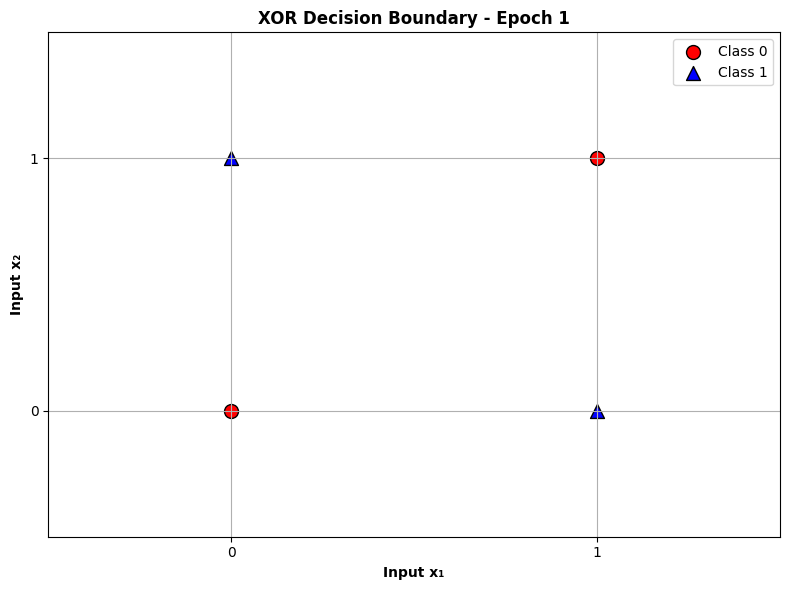

[0.  0.  0.5]


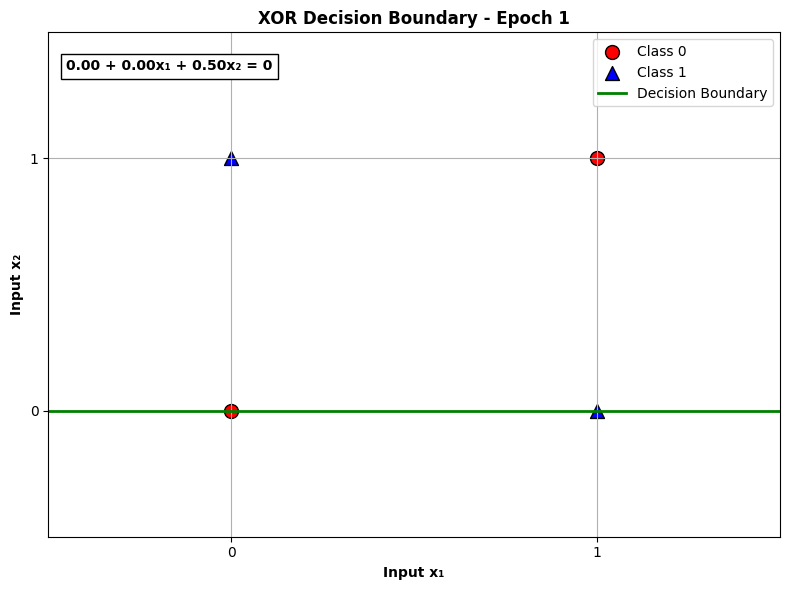

[0.  0.  0.5]
[-0.5 -0.5  0. ]


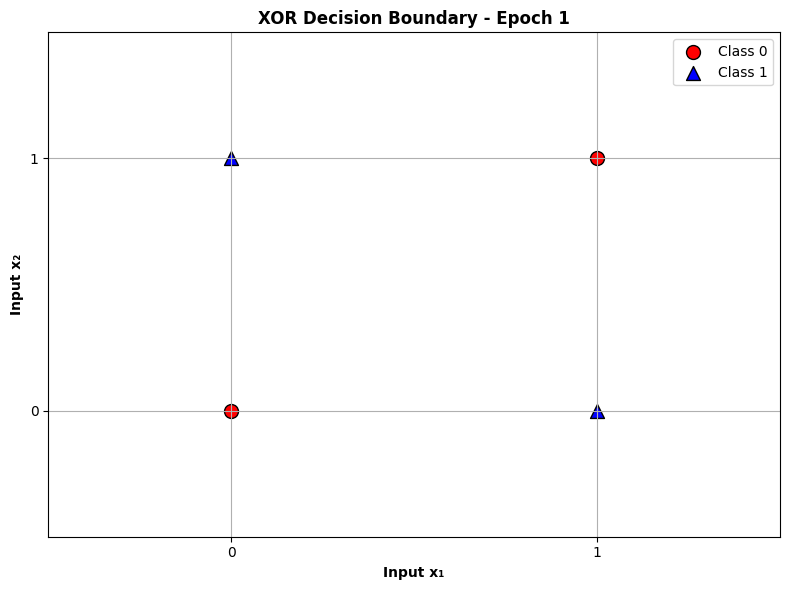

Epoch: 1
[-0.5 -0.5  0. ]
[ 0.  -0.5  0.5]


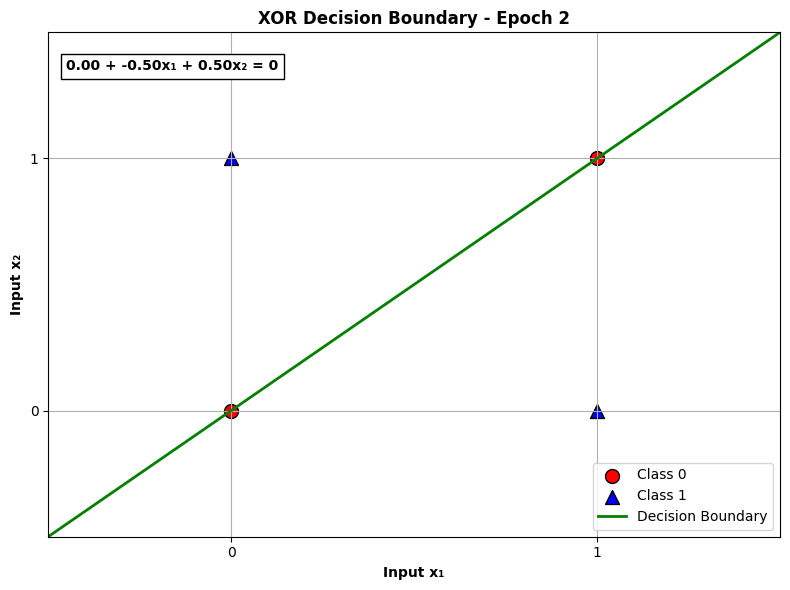

[0.5 0.  0.5]


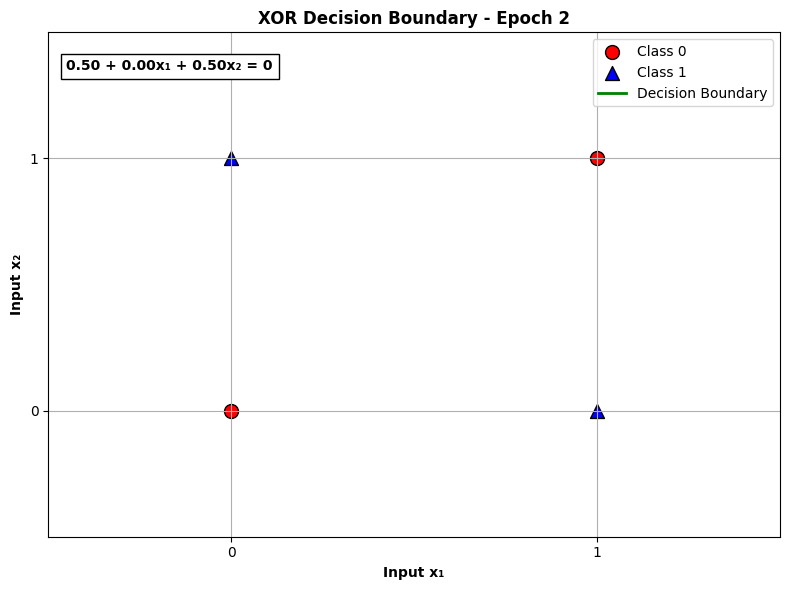

[ 0.  -0.5  0. ]


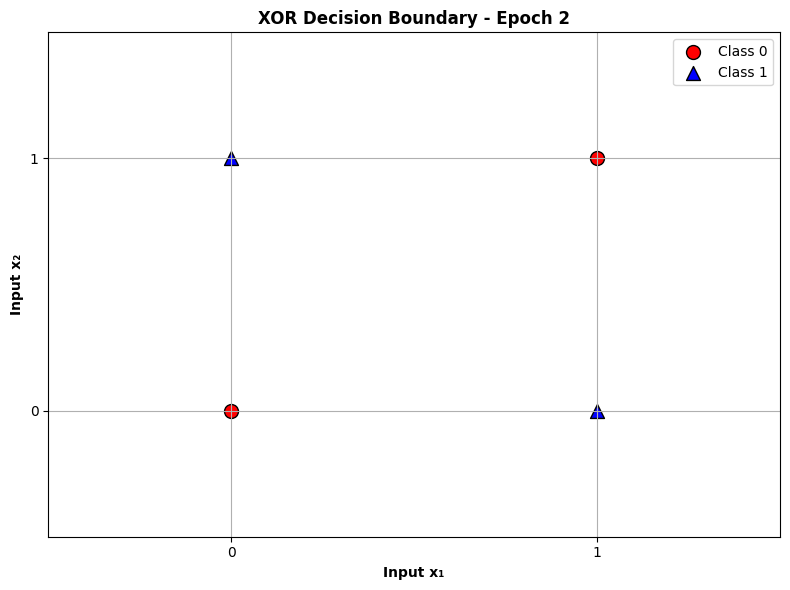

Epoch: 2
[-0.5 -0.5  0. ]


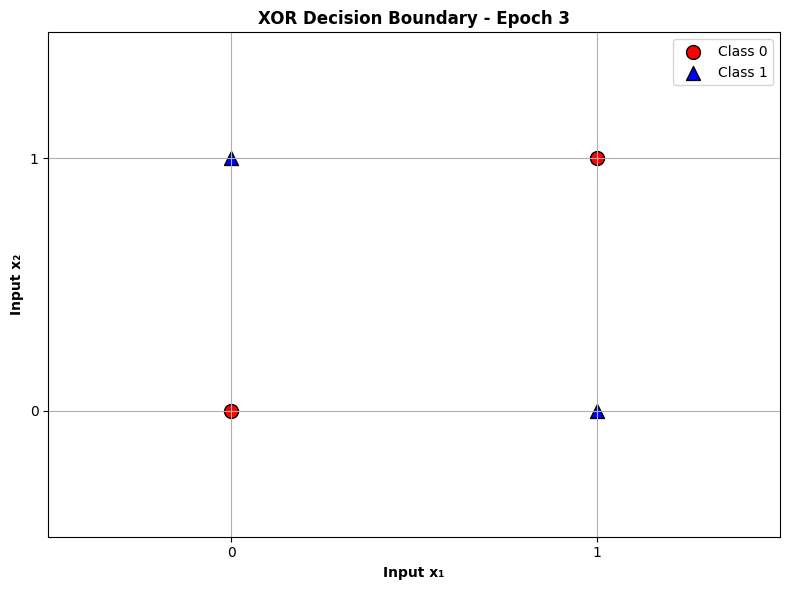

[ 0.  -0.5  0.5]


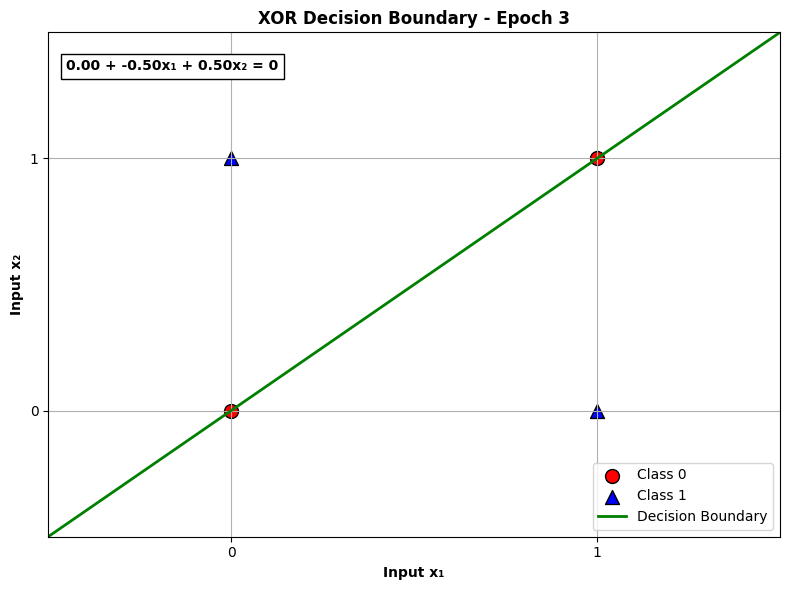

[0.5 0.  0.5]


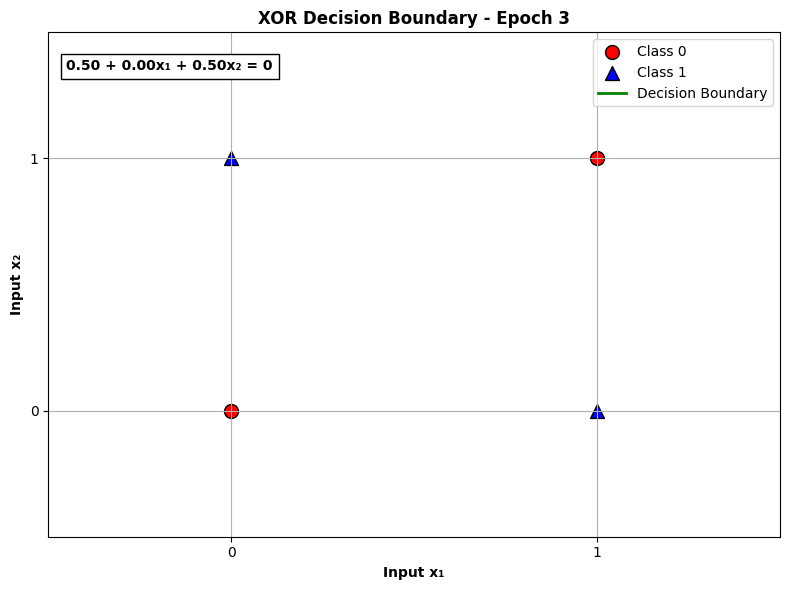

[ 0.  -0.5  0. ]


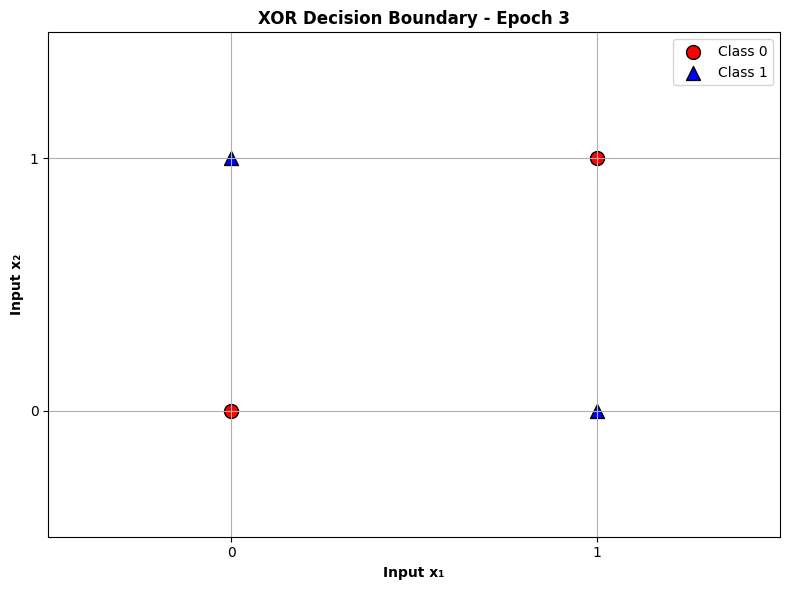

[ 0.  -0.5  0. ]


In [ ]:
# Train the model
weights = np.zeros(3,)
we = train_or_perceptron(X, y, weights)
print(we)

In [ ]:
#validate the model
correct = 0
for i in range(len(X)):
    x = X[i]
    y_pred = step_func(np.dot(we, x))
    if y_pred == y[i]:
        correct += 1

print("Accuracy:", correct, "/", len(X))

Accuracy: 2 / 4
